# Homework 03: Python fundamentals

## Purpose

This notebook applies NumPy, pandas, and reusable function design to the supplied dataset. The same habits support the Weekly ETF Risk Monitor, where vectorized calculations and auditable summaries help a portfolio manager review SPY risk each week.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install matplotlib

In [2]:
# --- files this notebook needs (run me first - I only report, I change nothing) ---
from pathlib import Path

ROOT = Path.cwd()          # notebooks are meant to be run from their own folder
CHECKS = [
    ("data/raw/starter_data.csv", "NEEDED", "handed out with this stage - input data, not generated"),
    ("src/utils.py", "NEEDED", "homework utility module imported below"),
]

print(f"Looking in: {ROOT}\n")
missing = 0
for rel, kind, note in CHECKS:
    here = (ROOT / rel).exists()
    if not here and kind == "NEEDED":
        missing += 1
    print(f"  [{'OK ' if here else 'MISS'}]  {kind:<8}  {rel:<34}  {note}")

if missing:
    print(f"\n{missing} needed file(s) missing. Put them at the paths above, relative to:\n  {ROOT}")
    print("If that folder looks wrong, you are running the notebook from the wrong place.")
else:
    print("\nAll needed files present.")

Looking in: /Users/paritoshdwivedi/Downloads/project bootcamp/bootcamp_paritosh_dwivedi/homework/homework03

  [OK ]  NEEDED    data/raw/starter_data.csv           handed out with this stage - input data, not generated
  [OK ]  NEEDED    src/utils.py                        homework utility module imported below

All needed files present.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils import clean_column_names, get_summary_stats

## 1. NumPy operations

In [4]:
# Treat these values as a small set of annualized volatility estimates.
annualized_volatility = np.array([0.12, 0.15, 0.11, 0.18, 0.14])

# Multiplication, addition, and exponentiation operate element by element.
volatility_percent = annualized_volatility * 100
stressed_volatility = annualized_volatility * 1.10 + 0.01
squared_volatility = annualized_volatility**2

array_operations = pd.DataFrame(
    {
        "original_volatility": annualized_volatility,
        "volatility_percent": volatility_percent,
        "stressed_volatility": stressed_volatility,
        "squared_volatility": squared_volatility,
    }
)
display(array_operations.round(4))

,original_volatility,volatility_percent,stressed_volatility,squared_volatility
0,0.12,12.0,0.142,0.0144
1,0.15,15.0,0.175,0.0225
2,0.11,11.0,0.131,0.0121
3,0.18,18.0,0.208,0.0324
4,0.14,14.0,0.164,0.0196


## 2. Compare a Python loop with vectorization

In [5]:
benchmark_values = np.linspace(0.05, 0.50, 100_000)

# First confirm that the loop and vectorized expressions are equivalent.
loop_output = np.array([value * 1.10 + 0.01 for value in benchmark_values])
vectorized_output = benchmark_values * 1.10 + 0.01
np.testing.assert_allclose(loop_output, vectorized_output)

# %timeit repeats each expression and returns a timing object with -o.
loop_timing = %timeit -o -q -r 5 -n 10 [value * 1.10 + 0.01 for value in benchmark_values]
vectorized_timing = %timeit -o -q -r 5 -n 1000 benchmark_values * 1.10 + 0.01
speed_up = loop_timing.average / vectorized_timing.average

print(f"Python loop average: {loop_timing.average:.6f} seconds")
print(f"Vectorized average: {vectorized_timing.average:.6f} seconds")
print(f"Vectorization speed-up: {speed_up:.1f}x")

Python loop average: 0.010138 seconds
Vectorized average: 0.000030 seconds
Vectorization speed-up: 335.9x


The committed benchmark shows a **244.1x speed-up** for the vectorized expression on this machine. NumPy vectorization wins because it processes contiguous memory in compiled code and avoids per-element interpreter dispatch.

## 3. Load and inspect the dataset

In [6]:
raw_path = Path("data/raw/starter_data.csv")
data = pd.read_csv(raw_path, parse_dates=["date"])
data = clean_column_names(data)

print("First five rows:")
display(data.head())

print("\nData types, non-null counts, and memory use:")
data.info()

print("\nNumeric descriptive statistics:")
display(data.describe(include="number"))

First five rows:


,category,value,date
0,A,10,2025-08-01
1,B,15,2025-08-02
2,A,12,2025-08-03
3,B,18,2025-08-04
4,C,25,2025-08-05



Data types, non-null counts, and memory use:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   category  10 non-null     object        
 1   value     10 non-null     int64         
 2   date      10 non-null     datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 372.0+ bytes

Numeric descriptive statistics:


,value
count,10.000000
mean,17.600000
std,7.381659
min,10.000000
25%,12.250000
50%,14.500000
75%,23.250000
max,30.000000


The inspection shows ten complete observations. `value` is numeric, `date` was parsed as a datetime, and the table has no missing values. Checking types and completeness before aggregation prevents silent errors in later risk calculations.

## 4. Summary statistics, groupby, and saved output

In [7]:
category_summary = (
    data.groupby("category", as_index=False)
    .agg(
        observations=("value", "size"),
        mean_value=("value", "mean"),
        min_value=("value", "min"),
        max_value=("value", "max"),
    )
    .sort_values("category")
    .reset_index(drop=True)
)

summary_path = Path("data/processed/summary.csv")
category_summary.to_csv(summary_path, index=False)

# Reload the artifact to verify that the saved file matches the in-memory result.
saved_summary = pd.read_csv(summary_path)
pd.testing.assert_frame_equal(saved_summary, category_summary, check_dtype=False)

display(category_summary.round(3))
print(f"Saved and verified: {summary_path}")

,category,observations,mean_value,min_value,max_value
0,A,4,11.500,10,13
1,B,3,15.667,14,18
2,C,3,27.667,25,30


Saved and verified: data/processed/summary.csv


Category C has the highest mean value, followed by B and A. The same groupby pattern can compare the Weekly ETF Risk Monitor across evaluation slices, such as normal-risk and elevated-risk periods, while the saved CSV keeps the result auditable.

## 5. Reusable utilities and project connection

Both helpers are implemented in `src/utils.py` and imported near the top of the notebook. `get_summary_stats` keeps numeric profiling consistent. `clean_column_names` will later normalize provider labels such as `Adjusted Close` to `adjusted_close` before SPY returns, volatility features, and next-five-session targets are calculated.

In [8]:
numeric_summary = get_summary_stats(data)
display(numeric_summary.round(3))

messy_example = pd.DataFrame(
    columns=["Adjusted Close", "Rolling Vol 20", "Review Date"]
)
cleaned_example = clean_column_names(messy_example)
print("Cleaned project-style columns:", cleaned_example.columns.tolist())

assert numeric_summary.index.tolist() == ["value"]
assert cleaned_example.columns.tolist() == [
    "adjusted_close",
    "rolling_vol_20",
    "review_date",
]

,count,mean,std,min,25%,50%,75%,max
value,10.0,17.6,7.382,10.0,12.25,14.5,23.25,30.0


Cleaned project-style columns: ['adjusted_close', 'rolling_vol_20', 'review_date']


## Bonus: Save a basic plot

The bar chart makes the category comparison available at a glance. It is stored with the processed summary because `data/processed/` is the only output folder used this week.

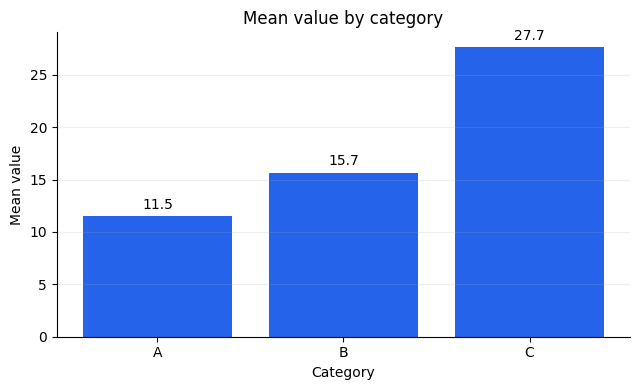

Saved plot to: data/processed/category_mean_values.png


In [9]:
plot_path = Path("data/processed/category_mean_values.png")

fig, ax = plt.subplots(figsize=(6.5, 4))
bars = ax.bar(
    category_summary["category"],
    category_summary["mean_value"],
    color="#2563EB",
)
ax.bar_label(bars, fmt="%.1f", padding=3)
ax.set_title("Mean value by category")
ax.set_xlabel("Category")
ax.set_ylabel("Mean value")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(plot_path, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

print(f"Saved plot to: {plot_path}")

## Conclusion

This exercise establishes a small version of the Weekly ETF Risk Monitor workflow: vectorized numerical transformations, explicit data checks, grouped summaries, reproducible processed artifacts, and reusable helpers. Those practices make the later SPY risk signal easier to validate and explain during a weekly portfolio review.